# CPP across data representations: scales, embeddings, and structure

A CPP feature is **part × split × value**: *where* in the sequence (`tmd`, `jmd_n_tmd_n`, `tmd_c_jmd_c`), *how* the positions are picked (`Segment` / `Pattern` / `PeriodicPattern`), and *what value* is summarized there. The value axis has two interchangeable sources that share one grammar and one `df_feat` schema:

- a physicochemical **amino acid scale** (the *sequence arm*, `CPP.run`), and
- any per-residue **numerical tensor** in `[0, 1]` (the *numerical arm*, `CPP.run_num`) — a protein language model (PLM) **embedding** or a **structural** channel.

So learned and structural representations ride the exact same interpretable CPP machinery. Below we feed three different representations of the **same proteins** into CPP and chart each one's `CPPPlot.feature_map` — the same map layout, but a different *kind* of feature each time. (The embedding and structure arms need the `aaanalysis[embed]` / `aaanalysis[pro]` extras.)

In [1]:
import tempfile
import aaanalysis as aa
import matplotlib.pyplot as plt
aa.options["verbose"] = False
aa.plot_settings()

# Same small protein set for every representation. n_jobs=1 keeps CPP
# deterministic and avoids the macOS process-spawn footgun.
df_seq = aa.load_dataset(name="DOM_GSEC", n=10)
labels = list(df_seq["label"])
cpp_plot = aa.CPPPlot(jmd_n_len=10, jmd_c_len=10)

def add_importance(df_feat):
    # Model-free importance for the map: each feature's discriminative power
    # (abs_auc), normalized to %. Swap in TreeModel.add_feat_importance for a
    # model-based ranking once you have a per-protein feature matrix.
    df_feat = df_feat.copy()
    df_feat["feat_importance"] = 100 * df_feat["abs_auc"] / df_feat["abs_auc"].sum()
    return df_feat

## Arm 1 — physicochemical scales (`CPP.run`)

The standard CPP: split the sequence parts and summarize **amino acid scale** values. The feature categories are the **AAontology** subcategories.

In [2]:
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
df_feat_scales = aa.CPP(df_scales=aa.load_scales(), df_parts=df_parts).run(
    labels=labels, n_filter=50, n_jobs=1)
df_feat_scales = add_importance(df_feat_scales)
aa.display_df(df_feat_scales, n_rows=10, show_shape=True)

CPP using the Python kernel fallback — the compiled Cython extension is not available in this install. Output is bit-exact with the Cython path but ~2x slower. Reinstall via `pip install --force-reinstall aaanalysis` to fetch a prebuilt wheel.


DataFrame shape: (50, 14)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions,feat_importance
1,"JMD_N_TMD_N-Seg...,10)-ZIMJ680101",Polarity,Hydrophobicity,Hydrophobicity,"Hydrophobicity ...n et al., 1968)",0.500000,0.361000,0.361000,0.156000,0.150000,0.000157,1.000000,"1,2",2.273244
2,"JMD_N_TMD_N-Pat...,12)-PALJ810110",Conformation,β-sheet,β-sheet,"Normalized freq...u et al., 1981)",0.470000,0.233000,-0.233000,0.092000,0.095000,0.000381,1.000000,"9,13,16,19",2.136849
3,"TMD-Pattern(N,1...,11)-PALJ810110",Conformation,β-sheet,β-sheet,"Normalized freq...u et al., 1981)",0.470000,0.233000,-0.233000,0.092000,0.095000,0.000381,1.000000,"11,15,18,21",2.136849
4,"TMD_C_JMD_C-Pat...,12)-TANS770105",Conformation,β-turn (C-term),β-turn (3rd residue),"Normalized freq...Scheraga, 1977)",0.470000,0.230000,-0.230000,0.061000,0.111000,0.000381,1.000000,"24,28,32",2.136849
5,"TMD_C_JMD_C-Pat...,15)-AURR980102",Conformation,Linker (6-14 AA),"α-helix (N-terminal, outside)","Normalized posi...ora-Rose, 1998)",0.465000,0.189000,0.189000,0.054000,0.099000,0.000440,1.000000,"26,29,33",2.114117
6,"TMD_C_JMD_C-Pat...,14)-AURR980102",Conformation,Linker (6-14 AA),"α-helix (N-terminal, outside)","Normalized posi...ora-Rose, 1998)",0.465000,0.189000,0.189000,0.054000,0.099000,0.000440,1.000000,"27,30,34",2.114117
7,"TMD-Pattern(C,4,8)-CHOP780201",Conformation,α-helix,α-helix,"Normalized freq...-Fasman, 1978b)",0.460000,0.279000,0.279000,0.095000,0.176000,0.000507,0.816292,"23,27",2.091384
8,"TMD_C_JMD_C-Pat...4,8)-CHOP780201",Conformation,α-helix,α-helix,"Normalized freq...-Fasman, 1978b)",0.460000,0.279000,0.279000,0.095000,0.176000,0.000507,1.000000,"24,28",2.091384
9,"TMD-Pattern(C,4,8)-RACS820114",Shape,Graph (2. eigenvalue),Side chain angle (Theta),"Value of theta(...Scheraga, 1982)",0.460000,0.201000,-0.201000,0.044000,0.133000,0.000507,1.000000,"23,27",2.091384
10,"TMD_C_JMD_C-Pat...4,8)-RACS820114",Shape,Graph (2. eigenvalue),Side chain angle (Theta),"Value of theta(...Scheraga, 1982)",0.460000,0.201000,-0.201000,0.044000,0.133000,0.000507,0.979550,"24,28",2.091384


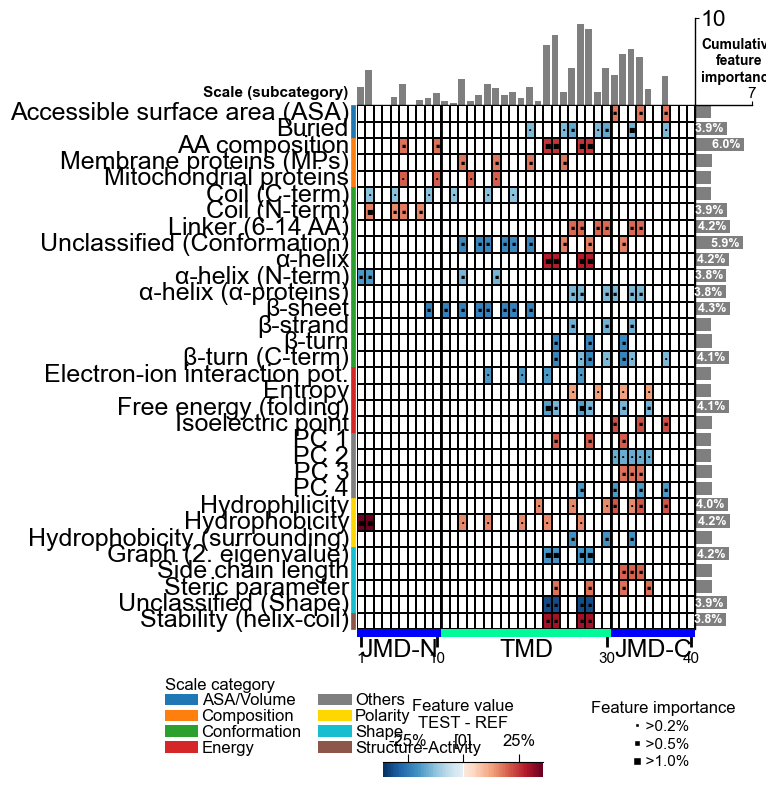

In [3]:
cpp_plot.feature_map(df_feat=df_feat_scales)
plt.tight_layout()
plt.show()

## Arm 2 — PLM embeddings (`CPP.run_num`)

Fetch per-residue ESM-2 embeddings, normalize them to `[0, 1]` with `EmbeddingPreprocessor.encode`, name the `D` channels as pseudo-scales, then run the **identical** CPP algorithm via `CPP.run_num`. The features are now *learned* embedding channels.

In [4]:
ep = aa.EmbeddingPreprocessor()
emb = ep.fetch_embeddings(df_seq, mode="residue", model="esm2_t6_8M")
dict_emb = ep.encode(df_seq=df_seq, embeddings=emb)              # raw -> [0, 1] per channel
df_scales_emb = ep.build_scales(df_seq=df_seq, dict_num=dict_emb)  # name the D channels
df_cat_emb = ep.build_cat(df_scales=df_scales_emb, random_state=42)
df_parts_emb, dict_num_parts_emb = aa.NumericalFeature.get_parts(df_seq=df_seq, dict_num=dict_emb)
df_feat_emb = aa.CPP(df_parts=df_parts_emb, df_scales=df_scales_emb, df_cat=df_cat_emb).run_num(
    dict_num_parts=dict_num_parts_emb, labels=labels, n_filter=50, n_jobs=1)
df_feat_emb = add_importance(df_feat_emb)
aa.display_df(df_feat_emb, n_rows=10, show_shape=True)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

/var/folders/sv/65tlch_10198qgmpwcp6408r0000gn/T/ipykernel_35276/333399537.py:4: UserWarning: Pseudo-scales are dataset-dependent (averaged over df_seq). For reproducible cross-dataset comparison, compute them once on a fixed reference corpus and reuse the resulting df_scales.
  df_scales_emb = ep.build_scales(df_seq=df_seq, dict_num=dict_emb)  # name the D channels


DataFrame shape: (50, 14)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions,feat_importance
1,"JMD_N_TMD_N-Pat...5,8,11)-dim_232",Embeddings,Embeddings_cat14_subcat206,dim_232,,0.500000,0.109000,0.109000,0.025000,0.038000,0.000157,0.497542,"2,5,8,11",2.151926
2,"JMD_N_TMD_N-Pat...,12,15)-dim_232",Embeddings,Embeddings_cat14_subcat206,dim_232,,0.500000,0.101000,0.101000,0.033000,0.039000,0.000157,1.000000,"6,9,13",2.151926
3,"TMD_C_JMD_C-Pat...C,2,5,9)-dim_10",Embeddings,Embeddings_cat0_subcat15,dim_10,,0.500000,0.099000,-0.099000,0.044000,0.033000,0.000157,0.226155,"32,36,39",2.151926
4,"JMD_N_TMD_N-Pat...,10,14)-dim_301",Embeddings,Embeddings_cat51_subcat267,dim_301,,0.500000,0.080000,0.080000,0.021000,0.033000,0.000157,0.355387,"7,11",2.151926
5,"JMD_N_TMD_N-Pat...N,9,13)-dim_301",Embeddings,Embeddings_cat51_subcat267,dim_301,,0.500000,0.080000,0.080000,0.021000,0.033000,0.000157,0.276412,"9,13",2.151926
6,"JMD_N_TMD_N-Pat...,1,5,8)-dim_204",Embeddings,Embeddings_cat23_subcat179,dim_204,,0.500000,0.075000,-0.075000,0.024000,0.032000,0.000157,0.310964,"1,5,8",2.151926
7,"JMD_N_TMD_N-Pat...,2,5,8)-dim_146",Embeddings,Embeddings_cat28_subcat132,dim_146,,0.490000,0.087000,-0.087000,0.035000,0.026000,0.000212,0.240070,"2,5,8",2.108887
8,"JMD_N_TMD_N-Seg...nt(2,7)-dim_232",Embeddings,Embeddings_cat14_subcat206,dim_232,,0.490000,0.082000,0.082000,0.024000,0.041000,0.000212,0.280081,"3,4,5",2.108887
9,"TMD_C_JMD_C-Seg...(11,13)-dim_107",Embeddings,Embeddings_cat18_subcat96,dim_107,,0.480000,0.126000,-0.126000,0.034000,0.056000,0.000285,0.167269,36,2.065849
10,"TMD_C_JMD_C-Pat...n(C,2,5)-dim_75",Embeddings,Embeddings_cat6_subcat65,dim_75,,0.480000,0.095000,0.095000,0.030000,0.037000,0.000285,0.215060,"36,39",2.065849


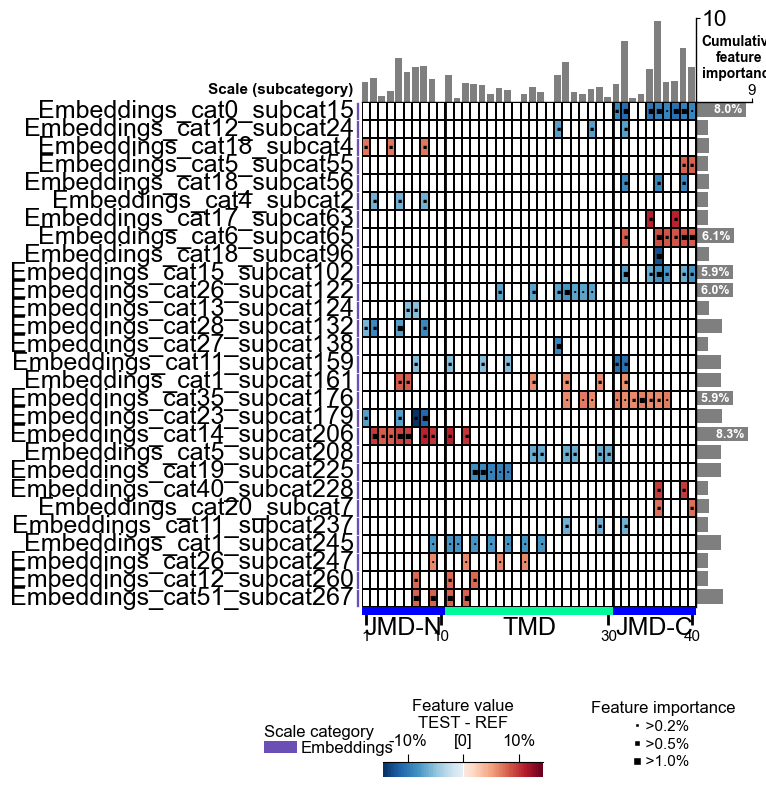

In [5]:
# feature_map needs the embedding's own pseudo-categories (df_cat_emb)
aa.CPPPlot(df_scales=df_scales_emb, df_cat=df_cat_emb,
           jmd_n_len=10, jmd_c_len=10).feature_map(df_feat=df_feat_emb)
plt.tight_layout()
plt.show()

## Arm 3 — structure / DSSP (`CPP.run_num`)

Fetch AlphaFold structures, derive per-residue **DSSP** channels (secondary structure, relative accessible surface area, backbone angles) with `StructurePreprocessor.encode_dssp`, and run CPP on them. The features are now *structural* channels. (`encode_dssp` drops any entry without a structure; we run CPP on the structured subset.)

In [6]:
FEATURES = ["ss3", "rasa", "phi_psi_sincos"]
stp = aa.StructurePreprocessor()
pdb_folder = tempfile.mkdtemp()
stp.fetch_alphafold(df_seq=df_seq, out_folder=pdb_folder, on_failure="nan")
dict_str = stp.encode_dssp(df_seq=df_seq, pdb_folder=pdb_folder, features=FEATURES, on_failure="drop")

df_seq_str = df_seq[df_seq["entry"].isin(dict_str)].reset_index(drop=True)
df_scales_str = stp.build_scales(df_seq=df_seq_str, dict_num=dict_str, features=FEATURES)
df_cat_str = stp.build_cat(features=FEATURES)
df_parts_str, dict_num_parts_str = aa.NumericalFeature.get_parts(df_seq=df_seq_str, dict_num=dict_str)
df_feat_str = aa.CPP(df_parts=df_parts_str, df_scales=df_scales_str, df_cat=df_cat_str).run_num(
    dict_num_parts=dict_num_parts_str, labels=list(df_seq_str["label"]), n_filter=50, n_jobs=1)
df_feat_str = add_importance(df_feat_str)
aa.display_df(df_feat_str, n_rows=10, show_shape=True)

/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)


/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)


/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)


/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)


/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)


...

/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)


/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)
/var/folders/sv/65tlch_10198qgmpwcp6408r0000gn/T/ipykernel_35276/32024336.py:8: UserWarning: Pseudo-scales are dataset-dependent (averaged over df_seq + dict_num). For reproducible cross-dataset comparison, compute them once on a fixed reference corpus and reuse the resulting df_scales.
  df_scales_str = stp.build_scales(df_seq=df_seq_str, dict_num=dict_str, features=FEATURES)


DataFrame shape: (27, 14)


/Users/stephanbreimann/Programming/1Packages/aaanalysis-cpp-representations/aaanalysis/feature_engineering/_backend/cpp_run.py:112: RuntimeWarning: 'n_filter' (50) should be <= the number of features the filter could deliver (27); returning fewer features than requested. Inspect ``df_feat.attrs['last_filter_stats']`` and consider a larger 'df_scales' / 'n_jmd' / less strict 'max_overlap'/'max_cor'.
  warnings.warn(


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions,feat_importance
1,"JMD_N_TMD_N-Seg...nt(1,2)-psi_sin",Structure,Backbone dihedral (sin/cos),psi_sin,Structure/Backb...edral (sin/cos),0.420000,0.183000,0.183000,0.185000,0.192000,0.001499,0.593554,"1,2,3,4,5,6,7,8,9,10",6.441718
2,"JMD_N_TMD_N-Pat...ern(N,2,5)-rasa",Structure,Relative ASA (Tien),rasa,Structure/Relative ASA (Tien),0.350000,0.238000,0.238000,0.164000,0.159000,0.008151,0.084942,"2,5",5.368098
3,"JMD_N_TMD_N-Segment(1,5)-rasa",Structure,Relative ASA (Tien),rasa,Structure/Relative ASA (Tien),0.340000,0.162000,0.162000,0.193000,0.132000,0.010165,0.087509,"1,2,3,4",5.214724
4,"JMD_N_TMD_N-Per...+3/3,1)-ss_coil",Structure,Secondary structure (3-state),ss_coil,Structure/Secon...cture (3-state),0.335000,0.126000,-0.126000,0.038000,0.102000,0.011330,0.083084,"2,5,8,11,14,17,20",5.138037
5,"JMD_N_TMD_N-Per...+3/3,1)-ss_coil",Structure,Secondary structure (3-state),ss_coil,Structure/Secon...cture (3-state),0.335000,0.126000,-0.126000,0.038000,0.102000,0.011330,0.081574,"1,4,7,10,13,16,19",5.138037
6,"JMD_N_TMD_N-Pat...5,8,11)-psi_cos",Structure,Backbone dihedral (sin/cos),psi_cos,Structure/Backb...edral (sin/cos),0.330000,0.211000,-0.211000,0.193000,0.145000,0.012611,0.076831,"1,5,8,11",5.061350
7,"JMD_N_TMD_N-Per...+4/3,4)-psi_cos",Structure,Backbone dihedral (sin/cos),psi_cos,Structure/Backb...edral (sin/cos),0.330000,0.120000,-0.120000,0.107000,0.098000,0.012611,0.079270,"3,6,10,13,17",5.061350
8,"JMD_N_TMD_N-Pat...(N,2,6,10)-rasa",Structure,Relative ASA (Tien),rasa,Structure/Relative ASA (Tien),0.320000,0.098000,0.098000,0.171000,0.105000,0.015564,0.071669,"2,6,10",4.907975
9,"JMD_N_TMD_N-Pat...,1,4,7,10)-rasa",Structure,Relative ASA (Tien),rasa,Structure/Relative ASA (Tien),0.300000,0.100000,0.100000,0.129000,0.104000,0.023342,0.088033,"1,4,7,10",4.601227
10,"JMD_N_TMD_N-Seg...t(6,15)-phi_sin",Structure,Backbone dihedral (sin/cos),phi_sin,Structure/Backb...edral (sin/cos),0.280000,0.091000,0.091000,0.194000,0.027000,0.034294,0.116071,"7,8",4.294479


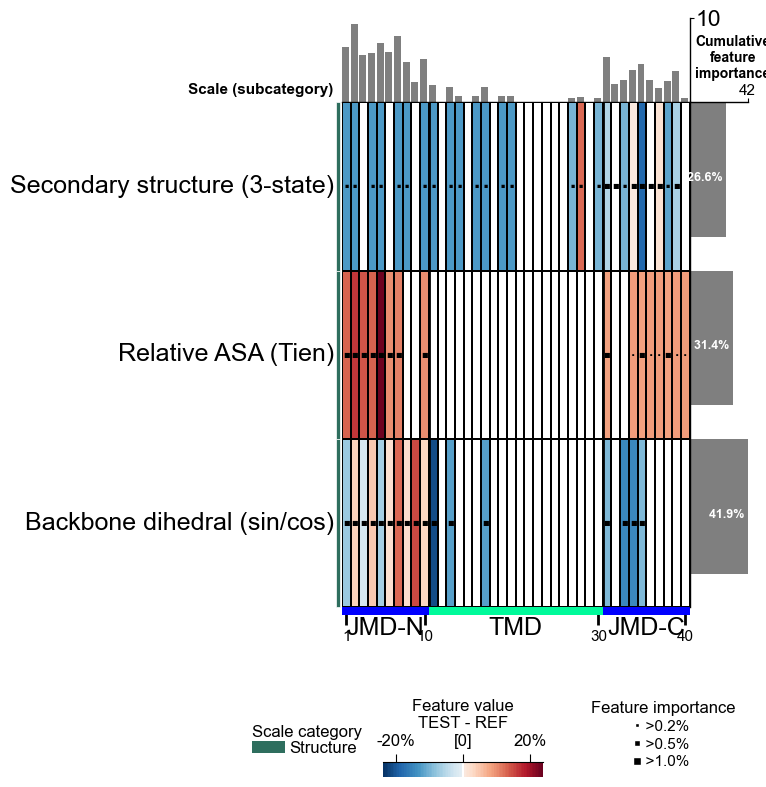

In [7]:
# feature_map needs the structure's own DSSP categories (df_cat_str)
aa.CPPPlot(df_scales=df_scales_str, df_cat=df_cat_str,
           jmd_n_len=10, jmd_c_len=10).feature_map(df_feat=df_feat_str)
plt.tight_layout()
plt.show()

## Same machinery, different features

All three maps share the **same layout and `df_feat` schema** — only the value source changed:

- **Scales** → interpretable AAontology categories (physicochemical signature).
- **Embeddings** → learned PLM channels (what the language model encodes).
- **Structure** → DSSP channels (secondary structure / accessibility / geometry).

Because they all produce the same `df_feat`, any of them feeds the same downstream tools — `CPPPlot`, `TreeModel`, `AAclust.select_proteins`, `ShapModel`. Pick the representation that matches the question; CPP turns each into an interpretable, position-aware feature set.